In [1]:
from transformers import CLIPProcessor, CLIPModel
import torch

# Load the CLIP model and processor
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

# Move model to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


CLIPModel(
  (text_model): CLIPTextTransformer(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 512)
      (position_embedding): Embedding(77, 512)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=512, out_features=2048, bias=True)
            (fc2): Linear(in_features=2048, out_features=512, bias=True)
          )
          (layer_norm2): LayerNorm((512,), eps=1e-05,

In [2]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import pandas as pd
from torchvision import transforms

class MultimodalDataset(Dataset):
    def __init__(self, dataframe, images_folder, tokenizer, image_transforms):
        self.dataframe = dataframe
        self.images_folder = images_folder
        self.tokenizer = tokenizer
        self.image_transforms = image_transforms

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        text = row['Caption']
        label = 1 if row['Label'] == 'fake' else 0
        image_id = row['Image id']

        image_path = os.path.join(self.images_folder, image_id)
        if not os.path.exists(image_path):
            raise FileNotFoundError(f"{image_path} not found")


        image = Image.open(image_path).convert("RGB")
        
        inputs = self.tokenizer(
            text=[text],
            images=image,
            return_tensors="pt",
            padding="max_length",
            truncation=True,
            max_length=77
        )

        label = int(label)
        assert 0 <= label < 2, f"Label {label} out of range"

        return {
            "input_ids": inputs["input_ids"].squeeze(0),
            "attention_mask": inputs["attention_mask"].squeeze(0),
            "pixel_values": inputs["pixel_values"].squeeze(0),
            "label": torch.tensor(label, dtype=torch.long)
        }


In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer
from torchvision import transforms
from PIL import Image
import os

# Load the CSV file
csv_path = '/kaggle/input/datasets/avijitsaha929/bhm-bangla-hate-meme/Dataset_text.csv'
df = pd.read_csv(csv_path)

# Verify column names
print(df.columns)

# Drop unnecessary columns if they exist
columns_to_drop = [col for col in ['Source', 'Domain', 'Unnamed: 5'] if col in df.columns]
df = df.drop(columns_to_drop, axis=1)

# Shuffle the dataframe
df = shuffle(df, random_state=42)

# Split the dataset
train_ratio = 0.6
val_ratio = 0.2
test_ratio = 0.2

train_data, val_test = train_test_split(df, train_size=train_ratio, random_state=42)
valid_data, test_data = train_test_split(val_test, train_size=val_ratio / (val_ratio + test_ratio), random_state=42)


Index(['Image id', 'Caption', 'Label'], dtype='object')


In [4]:
from torch.utils.data import DataLoader


# Define image folder path
images_folder = '/kaggle/input/datasets/avijitsaha929/bhm-bangla-hate-meme/Without text/'

# Create datasets
train_dataset = MultimodalDataset(train_data, images_folder, processor, None)
valid_dataset = MultimodalDataset(valid_data, images_folder, processor, None)
test_dataset = MultimodalDataset(test_data, images_folder, processor, None)

# Create data loaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


In [5]:
from transformers import CLIPProcessor, CLIPModel
import torch.nn as nn
import torch.optim as optim
import torch

class CLIPClassifier(nn.Module):
    def __init__(self, clip_model, embed_dim, num_labels):
        super(CLIPClassifier, self).__init__()
        self.clip_model = clip_model
        self.text_projection = nn.Linear(embed_dim, embed_dim)
        self.image_projection = nn.Linear(embed_dim, embed_dim)
        self.classifier = nn.Linear(embed_dim * 2, num_labels)
    
    def forward(self, input_ids, attention_mask, pixel_values):
        outputs = self.clip_model(input_ids=input_ids, attention_mask=attention_mask, pixel_values=pixel_values)
        text_embeds = outputs.text_embeds  # Use the text embeddings
        image_embeds = outputs.image_embeds
        
        # Project the embeddings
        text_embeds = self.text_projection(text_embeds)
        image_embeds = self.image_projection(image_embeds)
        
        # Concatenate the embeddings
        combined_embeds = torch.cat((text_embeds, image_embeds), dim=1)
        logits = self.classifier(combined_embeds)
        
        return logits

# Load the CLIP model and processor
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

# Move model to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

# Initialize the classifier
embed_dim = 512  # The embedding dimension for CLIP
num_labels = 2
clip_classifier = CLIPClassifier(model, embed_dim, num_labels)
clip_classifier.to(device)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(clip_classifier.parameters(), lr=1e-4)

# Training and evaluation functions
def train_one_epoch(model, data_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct_predictions = 0

    for batch in data_loader:
        optimizer.zero_grad()

        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        pixel_values = batch['pixel_values'].to(device)
        labels = batch['label'].to(device)

        outputs = model(input_ids, attention_mask, pixel_values)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * input_ids.size(0)
        _, preds = torch.max(outputs, 1)
        correct_predictions += torch.sum(preds == labels.data)

    epoch_loss = running_loss / len(data_loader.dataset)
    epoch_acc = correct_predictions.double() / len(data_loader.dataset)

    return epoch_loss, epoch_acc

def validate_one_epoch(model, data_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct_predictions = 0

    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            pixel_values = batch['pixel_values'].to(device)
            labels = batch['label'].to(device)

            outputs = model(input_ids, attention_mask, pixel_values)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * input_ids.size(0)
            _, preds = torch.max(outputs, 1)
            correct_predictions += torch.sum(preds == labels.data)

    epoch_loss = running_loss / len(data_loader.dataset)
    epoch_acc = correct_predictions.double() / len(data_loader.dataset)

    return epoch_loss, epoch_acc

# Training loop
num_epochs = 10
best_acc = 0.0

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(clip_classifier, train_loader, criterion, optimizer, device)
    valid_loss, valid_acc = validate_one_epoch(clip_classifier, valid_loader, criterion, device)

    print(f'Epoch {epoch+1}/{num_epochs}')
    print(f'Train Loss: {train_loss:.4f} Acc: {train_acc:.4f}')
    print(f'Valid Loss: {valid_loss:.4f} Acc: {valid_acc:.4f}')

    if valid_acc > best_acc:
        best_acc = valid_acc
        torch.save(clip_classifier.state_dict(), 'best_clip_classifier.pth')

print('Training complete')

# Load the best model for evaluation
clip_classifier.load_state_dict(torch.load('best_clip_classifier.pth'))


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1/10
Train Loss: 0.4580 Acc: 0.8433
Valid Loss: 0.3148 Acc: 0.8911
Epoch 2/10
Train Loss: 0.2113 Acc: 0.9330
Valid Loss: 0.2070 Acc: 0.9389
Epoch 3/10
Train Loss: 0.1211 Acc: 0.9670
Valid Loss: 0.1025 Acc: 0.9744
Epoch 4/10
Train Loss: 0.1276 Acc: 0.9667
Valid Loss: 0.1312 Acc: 0.9689
Epoch 5/10
Train Loss: 0.1075 Acc: 0.9685
Valid Loss: 0.0608 Acc: 0.9822
Epoch 6/10
Train Loss: 0.0480 Acc: 0.9863
Valid Loss: 0.0522 Acc: 0.9833
Epoch 7/10
Train Loss: 0.0356 Acc: 0.9911
Valid Loss: 0.0557 Acc: 0.9833
Epoch 8/10
Train Loss: 0.0369 Acc: 0.9915
Valid Loss: 0.0309 Acc: 0.9922
Epoch 9/10
Train Loss: 0.0207 Acc: 0.9944
Valid Loss: 0.0346 Acc: 0.9922
Epoch 10/10
Train Loss: 0.0178 Acc: 0.9959
Valid Loss: 0.0878 Acc: 0.9744
Training complete


<All keys matched successfully>

In [6]:
#model.load_state_dict(torch.load('best_clip_classifier.pth'))
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

def evaluate_model(model, data_loader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            pixel_values = batch['pixel_values'].to(device)
            labels = batch['label'].to(device)

            outputs = model(input_ids, attention_mask, pixel_values)
            _, preds = torch.max(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_labels = ['fake' if label == 1 else 'real' for label in all_labels]
    all_preds = ['fake' if pred == 1 else 'real' for pred in all_preds]

    
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='weighted')
    recall = recall_score(all_labels, all_preds, average='weighted')
    f1 = f1_score(all_labels, all_preds, average='weighted')
    report = classification_report(all_labels, all_preds, target_names=['fake', 'real'])

    return accuracy, precision, recall, f1, report, all_labels, all_preds

# Evaluate the model on the test dataset
accuracy, precision, recall, f1, report, all_labels, all_preds = evaluate_model(clip_classifier, test_loader, device)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print("\nClassification Report:")
print(report)


Accuracy: 0.9922
Precision: 0.9923
Recall: 0.9922
F1 Score: 0.9922

Classification Report:
              precision    recall  f1-score   support

        fake       0.99      1.00      0.99       436
        real       1.00      0.99      0.99       464

    accuracy                           0.99       900
   macro avg       0.99      0.99      0.99       900
weighted avg       0.99      0.99      0.99       900



In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(all_labels, all_preds):
    labels = ['fake', 'real']
    cm = confusion_matrix(all_labels, all_preds, labels=labels)
    plt.figure(figsize=(8, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.savefig('/kaggle/working/ViT_confusion_matrix.png')
    plt.show()
    

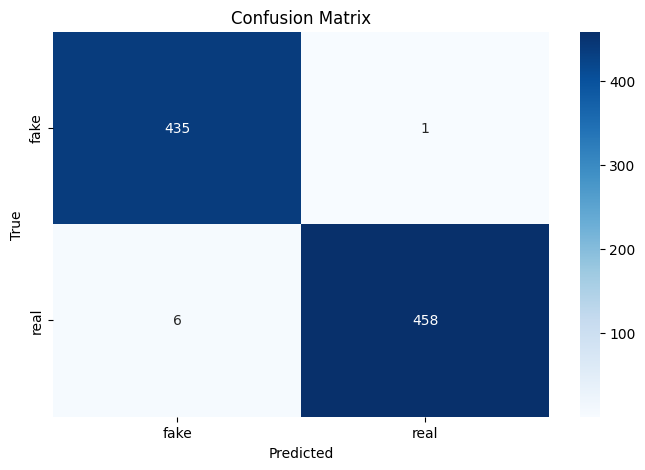

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
plot_confusion_matrix(all_labels, all_preds)